# 04  Exposure-duration risk

This notebook tests whether storm movement speed has changed between 1988 and 2023. Slower-moving storms can keep damaging wind and rainfall conditions over affected areas for longer, increasing the potential for flood accumulation, infrastructure downtime, business interruption, and claims severity.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

#Bootstrap settings
RNG = np.random.default_rng(42)
N_BOOTSTRAP = 1000
MIN_STORMS_PER_YEAR = 3
ANALYSIS_BASINS = ['WP', 'EP', 'NA', 'SI', 'SP']

HOURS_PER_OBS = 6  

HIGH_INTENSITY_THRESHOLD = 58.1   # m/s

In [ ]:
# Load storm-level and timestep-level data
storms = pd.read_parquet("../data/processed/storms_analysis.parquet")
tracks = pd.read_parquet("../data/processed/tracks_analysis.parquet")

START_YEAR = 1988
END_YEAR = 2023

storms = storms[
    storms["basin"].isin(ANALYSIS_BASINS)
    & storms["year"].between(START_YEAR, END_YEAR)
].copy()

tracks = tracks[
    tracks["basin"].isin(ANALYSIS_BASINS)
    & tracks["year"].between(START_YEAR, END_YEAR)
].copy()

print(f"Loaded {len(storms):,} storms and {len(tracks):,} track records")
print(f"Year range: {storms['year'].min()} to {storms['year'].max()}")

basin_counts = (
    storms.groupby("basin")
    .size()
    .reindex(ANALYSIS_BASINS)
    .rename("n_storms")
    .to_frame()
)

display(basin_counts)

Loaded 2,424 storms and 80,688 track records
Year range: 1988 to 2023


,n_storms
basin,
WP,851
EP,497
NA,411
SI,435
SP,230


## Translation speed

Translation speed is used as the main exposure-duration indicator. A decreasing trend means storms are moving more slowly, which may increase local exposure duration for affected regions.

The formal test uses yearly basin-level mean translation speed.

In [3]:
# Yearly mean translation speed by basin

yearly_speed = (
    storms
    .dropna(subset=["mean_translation_kmh"])
    .groupby(["basin", "year"])
    .agg(
        n_storms=("mean_translation_kmh", "size"),
        mean_speed=("mean_translation_kmh", "mean")
    )
    .reset_index()
)

# Remove very small basin-year cells
yearly_speed = yearly_speed[yearly_speed["n_storms"] >= MIN_STORMS_PER_YEAR].copy()
yearly_speed = yearly_speed.sort_values(["basin", "year"])

decadal_speed = yearly_speed.copy()
decadal_speed["decade"] = (decadal_speed["year"] // 10) * 10

print("Years retained per basin:")
print(yearly_speed.groupby("basin").size().reindex(ANALYSIS_BASINS).to_string())

Years retained per basin:
basin
WP    36
EP    36
NA    36
SI    36
SP    35


### Exploratory period view

Storms grouped into broad periods first, to see whether later periods differ from earlier ones. Error bars show bootstrap 95% CIs.

In [ ]:
def bootstrap_mean(values, n_boot=N_BOOTSTRAP, ci=95, rng=RNG):
    """Bootstrap 95% CI for a mean, returned in input units."""

    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    n = len(values)
    if n == 0:
        return np.nan, np.nan, np.nan
    
    point = values.mean()
    if n < 2:
        return point, np.nan, np.nan
    
    indices = rng.integers(0, n, size=(n_boot, n))
    boot_means = values[indices].mean(axis=1)
    
    alpha = (100 - ci) / 2
    lower = np.percentile(boot_means, alpha)
    upper = np.percentile(boot_means, 100 - alpha)
    return point, lower, upper


In [5]:
rows = []
for basin in ANALYSIS_BASINS:
    basin_data = decadal_speed[decadal_speed["basin"] == basin]
    
    for decade in sorted(basin_data["decade"].unique()):
        period_data = basin_data[basin_data["decade"] == decade]
        
        # Filter applied upstream on yearly cells (n_storms >= 3);
        # here the unit of variation is the basin-year mean.
        point, lower, upper = bootstrap_mean(period_data["mean_speed"])
        
        rows.append({
            "basin": basin,
            "decade": decade,
            "n_years": len(period_data),
            "mean_speed": point,
            "ci_lower": lower,
            "ci_upper": upper,
        })

decade_summary = pd.DataFrame(rows)

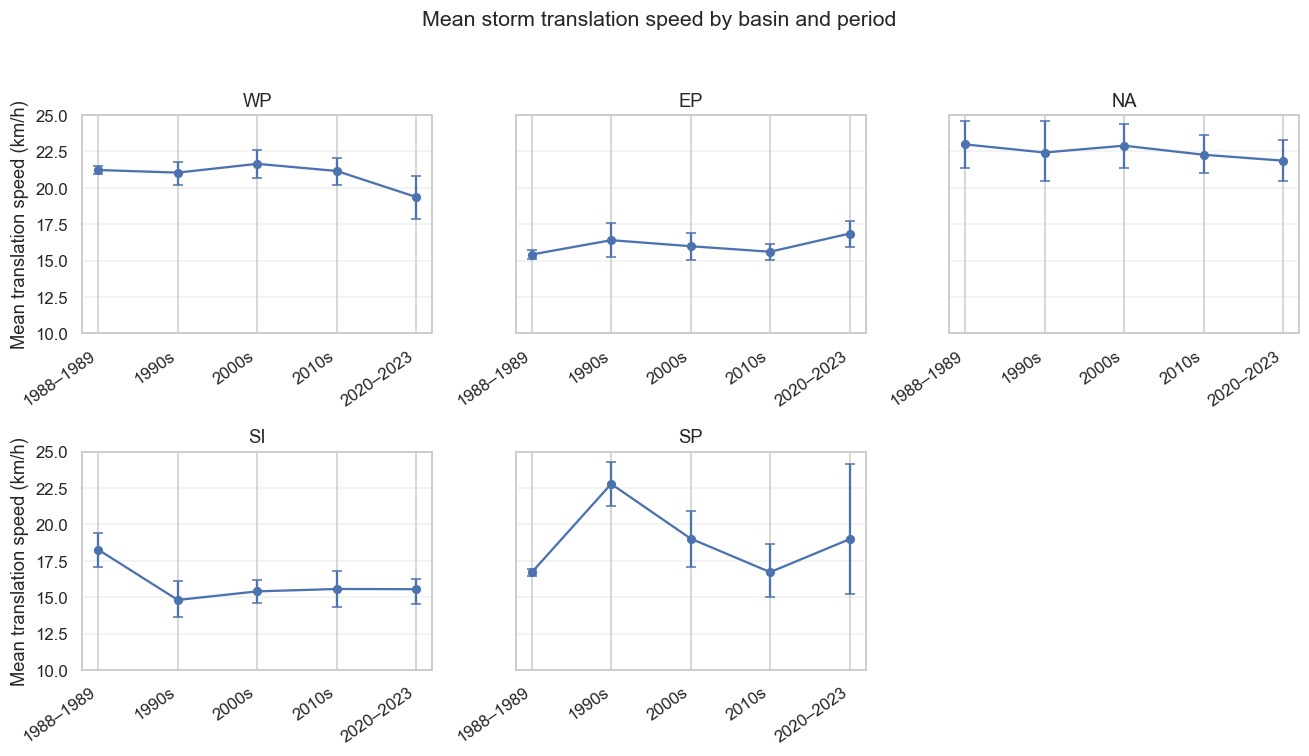

In [6]:
def label_period(decade):
    if decade == 1980:
        return "1988–1989"
    if decade == 2020:
        return "2020–2023"
    return f"{decade}s"


# Plot decadal mean translation speed with bootstrap confidence intervals
plot_df = decade_summary.copy()
plot_df["period"] = plot_df["decade"].apply(label_period)

period_order = ["1988–1989", "1990s", "2000s", "2010s", "2020–2023"]
x_positions = {period: i for i, period in enumerate(period_order)}
plot_df["x"] = plot_df["period"].map(x_positions)

y_max = np.ceil(plot_df["ci_upper"].max() / 5) * 5
y_min = np.floor(plot_df["ci_lower"].min() / 5) * 5

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey=True)
axes = axes.flatten()

for ax, basin in zip(axes, ANALYSIS_BASINS):
    basin_data = plot_df[plot_df["basin"] == basin].sort_values("x")
    
    yerr = np.vstack([
        basin_data["mean_speed"] - basin_data["ci_lower"],
        basin_data["ci_upper"] - basin_data["mean_speed"]
    ])
    
    ax.errorbar(
        basin_data["x"],
        basin_data["mean_speed"],
        yerr=yerr,
        fmt="o-",
        capsize=3,
        linewidth=1.5,
        markersize=5
    )
    
    ax.set_title(basin)
    ax.set_xticks(range(len(period_order)))
    ax.set_xticklabels(period_order, rotation=35, ha="right")
    ax.set_ylim(y_min, y_max)
    ax.grid(True, axis="y", alpha=0.3)

axes[-1].axis("off")

axes[0].set_ylabel("Mean translation speed (km/h)")
axes[3].set_ylabel("Mean translation speed (km/h)")

fig.suptitle(
    "Mean storm translation speed by basin and period",
    fontsize=14,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

WP, EP, NA, and SI sit close to flat across periods within their confidence intervals. SP is the most volatile, with a high 1990s mean followed by lower 2000s and 2010s means and a wide-CI uptick in the partial 2020-2023 window.

Decade bins can hide yearly patterns, and the first and last periods are incomplete, so the formal trend evidence comes from yearly basin-level shares.

In [7]:
trend_results_speed = []

for basin in ANALYSIS_BASINS:
    sub = yearly_speed[yearly_speed["basin"] == basin].sort_values("year")
    
    if len(sub) < 10:
        continue
    
    x = sub["year"].to_numpy()
    y = sub["mean_speed"].to_numpy()
    
    # Rank-based trend check
    tau, p_value = stats.kendalltau(x, y)
    
    # Simple descriptive slope
    ols_result = stats.linregress(x, y)
    ols_decade = ols_result.slope * 10
    
    # Robust median-based slope with rank-based CI
    ts_result = stats.theilslopes(y, x, alpha=0.95, method="separate")
    ts_decade = ts_result.slope * 10
    ts_low = ts_result.low_slope * 10
    ts_high = ts_result.high_slope * 10
    
    trend_results_speed.append({
        "Basin": basin,
        "Years": len(sub),
        "Kendall tau": round(tau, 3),
        "p-value": round(p_value, 3),
        "OLS (km/h per decade)": round(ols_decade, 2),
        "Theil-Sen (km/h per decade)": round(ts_decade, 2),
        "Theil-Sen 95% CI": f"[{ts_low:.2f}, {ts_high:.2f}]",
    })

trend_speed = pd.DataFrame(trend_results_speed)

display(trend_speed.style.hide(axis="index"))

Basin,Years,Kendall tau,p-value,OLS (km/h per decade),Theil-Sen (km/h per decade),Theil-Sen 95% CI
WP,36,-0.076000,0.513000,-0.230000,-0.240000,"[-0.72, 0.27]"
EP,36,0.038000,0.744000,-0.020000,0.080000,"[-0.40, 0.55]"
NA,36,0.006000,0.957000,-0.160000,0.040000,"[-1.15, 1.00]"
SI,36,0.035000,0.764000,0.070000,0.140000,"[-0.55, 0.74]"
SP,35,-0.382000,0.001000,-1.680000,-2.110000,"[-3.22, -0.80]"


South Pacific is the only basin with clear evidence of a change in translation speed. Theil-Sen estimates a decline of about 2.1 km/h per decade, with a 95% confidence interval that stays below zero [-3.2, -0.8]. The Kendall test is also statistically meaningful (p = 0.001), and OLS points in the same direction at -1.7 km/h per decade.

The agreement between OLS and Theil-Sen reduces the concern that the result is relying on a few unusual years.

The other four basins do not show clear evidence of a translation-speed shift. Their Kendall p-values are not statistically meaningful, their Theil-Sen point estimates are close to zero, and all confidence intervals span zero.

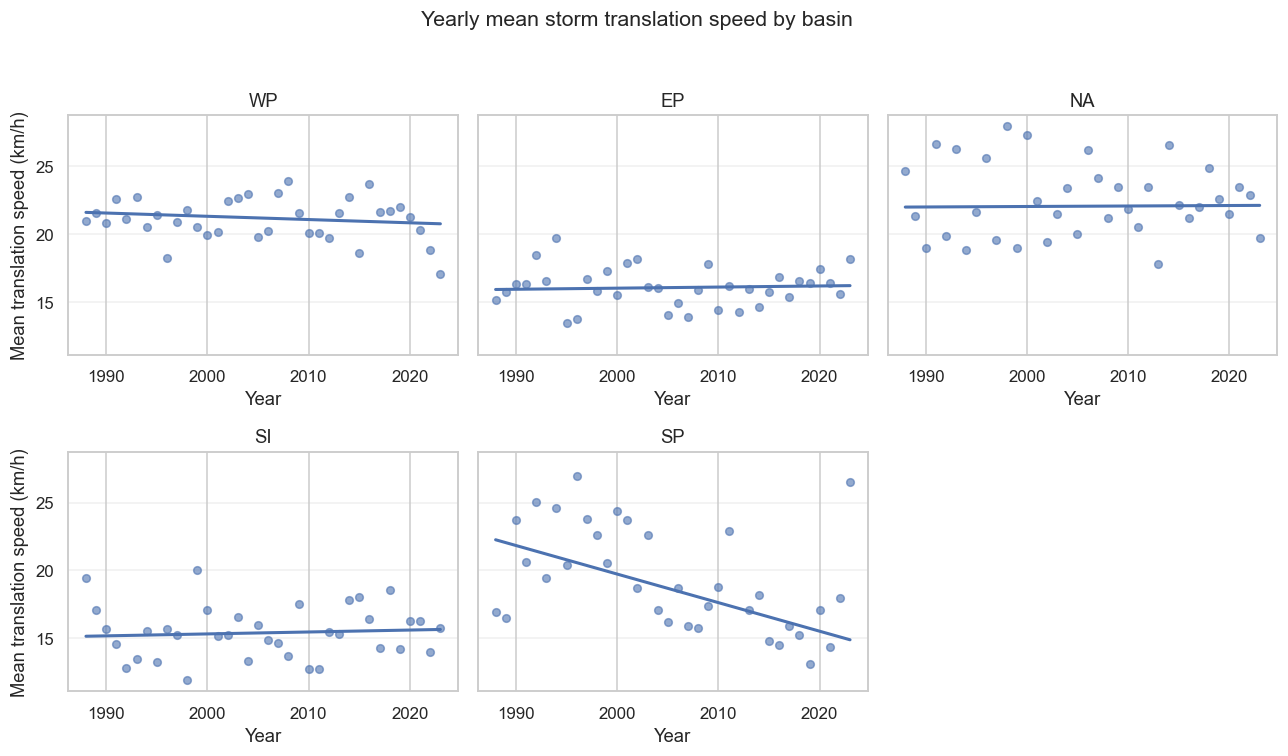

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey=True)
axes = axes.flatten()

for ax, basin in zip(axes, ANALYSIS_BASINS):
    sub = yearly_speed[yearly_speed["basin"] == basin].sort_values("year")
    
    ax.scatter(
        sub["year"],
        sub["mean_speed"],
        alpha=0.6,
        s=25
    )
    
    if len(sub) >= 3:
        ts = stats.theilslopes(
            sub["mean_speed"],
            sub["year"],
            alpha=0.95,
            method="separate"
        )
        
        x_line = np.array([sub["year"].min(), sub["year"].max()])
        y_line = ts.intercept + ts.slope * x_line
        
        ax.plot(x_line, y_line, linewidth=2)
    
    ax.set_title(basin)
    ax.set_xlabel("Year")
    ax.grid(True, axis="y", alpha=0.3)

axes[-1].axis("off")

axes[0].set_ylabel("Mean translation speed (km/h)")
axes[3].set_ylabel("Mean translation speed (km/h)")

fig.suptitle(
    "Yearly mean storm translation speed by basin",
    fontsize=14,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

The yearly plots support the trend table: SP shows a clear downward slope, while WP, EP, NA, and SI show no meaningful movement-speed trend.

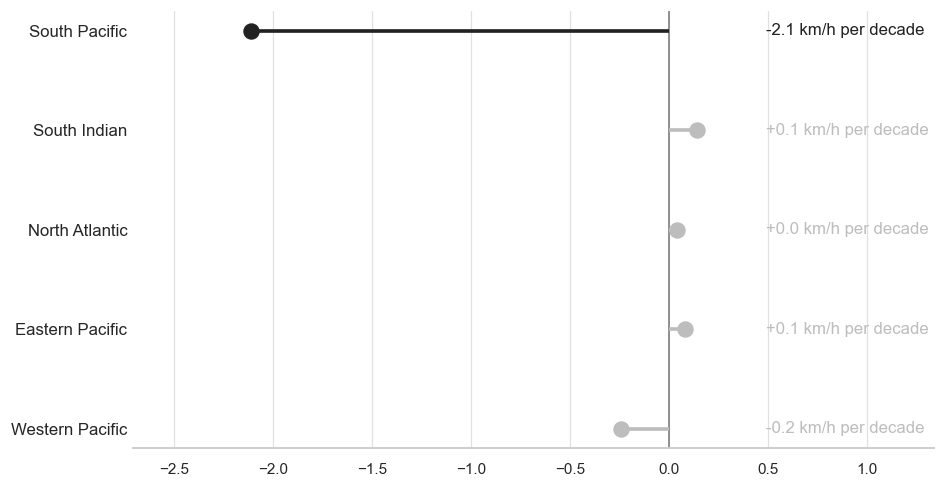

In [9]:
# Build plot data from the movement trend table
plot_df = trend_speed.copy()

basin_name_map = {
    "WP": "Western Pacific",
    "EP": "Eastern Pacific",
    "NA": "North Atlantic",
    "SI": "South Indian",
    "SP": "South Pacific"
}

plot_df["basin_name"] = plot_df["Basin"].map(basin_name_map)
plot_df["change_kmh_per_decade"] = plot_df["Theil-Sen (km/h per decade)"]

# Highlight only statistically meaningful slowdown
plot_df["signal"] = np.where(
    (plot_df["p-value"] < 0.05) & (plot_df["change_kmh_per_decade"] < 0),
    "meaningful slowdown",
    "no meaningful movement trend"
)

order = [
    "Western Pacific",
    "Eastern Pacific",
    "North Atlantic",
    "South Indian",
    "South Pacific",
]

plot_df["basin_name"] = pd.Categorical(
    plot_df["basin_name"],
    categories=order,
    ordered=True
)

plot_df = plot_df.sort_values("basin_name")

color_map = {
    "meaningful slowdown": "#222222",
    "no meaningful movement trend": "#BDBDBD"
}

fig, ax = plt.subplots(figsize=(8.8, 4.6))

ax.axvline(0, color="#8A8A8A", linewidth=1.2)

# Fixed right-hand label column
min_x = plot_df["change_kmh_per_decade"].min()
max_x = plot_df["change_kmh_per_decade"].max()

ax.set_xlim(min_x - 0.6, max_x + 1.2)
label_x = max_x + 0.35

for _, row in plot_df.iterrows():
    basin = row["basin_name"]
    x = row["change_kmh_per_decade"]
    color = color_map[row["signal"]]
    
    ax.hlines(
        y=basin,
        xmin=min(0, x),
        xmax=max(0, x),
        color=color,
        linewidth=2.4
    )
    
    ax.scatter(
        x,
        basin,
        color=color,
        s=95,
        zorder=3
    )
    
    ax.text(
        label_x,
        basin,
        f"{x:+.1f} km/h per decade",
        va="center",
        ha="left",
        fontsize=11,
        color=color
    )


ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")

ax.tick_params(axis="y", length=0, labelsize=11)
ax.tick_params(axis="x", labelsize=10)

ax.grid(axis="x", color="#E0E0E0", linewidth=0.8)
ax.grid(axis="y", visible=False)

plt.tight_layout()

plt.show()

## Secondary check: persistence above the high-intensity threshold

High-intensity exposure persistence is measured as the number of six-hourly observations where a storm is recorded at or above the 58.1 m/s wind threshold. This is an observed persistence proxy, not an exact continuous-duration measure. The metric is calculated only among storms that reached the threshold at least once.

In [ ]:
# Count 6-hourly high-intensity observations per storm

high_int_counts = (
    tracks.loc[tracks["wind_ms"] >= HIGH_INTENSITY_THRESHOLD]
    .groupby("storm_id")
    .size()
    .rename("high_intensity_obs")
    .reset_index()
)


storms = storms.drop(
    columns=["high_intensity_obs", "high_intensity_hours", "reached_high_intensity"],
    errors="ignore"
)

storms = storms.merge(high_int_counts, on="storm_id", how="left")

storms["high_intensity_obs"] = storms["high_intensity_obs"].fillna(0).astype(int)
storms["high_intensity_hours"] = storms["high_intensity_obs"] * 6
storms["reached_high_intensity"] = storms["high_intensity_obs"] > 0

# Main subset for this secondary check
high_intensity_storms = storms[storms["reached_high_intensity"]].copy()

print(f"Storms reaching ≥{HIGH_INTENSITY_THRESHOLD} m/s: {len(high_intensity_storms):,}")
print(f"Share of full sample: {len(high_intensity_storms) / len(storms) * 100:.1f}%")

Storms reaching ≥58.1 m/s: 320
Share of full sample: 13.2%


The table below summarises how long storms remain above the 58.1 m/s threshold, among storms that reached that threshold at least once. 

In [11]:
duration_summary = (
    high_intensity_storms
    .groupby("basin")["high_intensity_obs"]
    .agg(
        n_high_intensity_storms="count",
        mean_obs="mean",
        median_obs="median",
        p90_obs=lambda x: x.quantile(0.9),
        max_obs="max"
    )
    .reindex(ANALYSIS_BASINS)
    .round(1)
)

display(duration_summary)

,n_high_intensity_storms,mean_obs,median_obs,p90_obs,max_obs
basin,,,,,
WP,82,4.8,4.0,8.0,14
EP,117,5.3,4.0,10.4,22
NA,70,8.1,5.0,18.2,33
SI,32,3.3,3.0,5.9,9
SP,19,5.2,5.0,8.2,11


The storm-level persistence measure is aggregated into yearly basin-level averages. Very small basin-year cells are removed so that the yearly mean is not driven by one or two storms.

In [ ]:
def compute_yearly_mean_duration(hi_storms_df, min_n=3):
    """Per basin-year, mean high-intensity duration among high-intensity storms."""

    yearly = (
        hi_storms_df
        .groupby(["basin", "year"])
        .agg(
            n_hi_storms=("high_intensity_obs", "size"),
            mean_obs=("high_intensity_obs", "mean"),
            median_obs=("high_intensity_obs", "median"),
        )
        .reset_index()
    )
    return yearly[yearly['n_hi_storms'] >= min_n].reset_index(drop=True)


yearly_dur = compute_yearly_mean_duration(high_intensity_storms)

print("Years per basin:")
print(yearly_dur.groupby('basin').size().reindex(ANALYSIS_BASINS).to_string())


Years per basin:
basin
WP    13
EP    19
NA     9
SI     4
SP     1


In [13]:
trend_results = []

for basin in ANALYSIS_BASINS:
    sub = yearly_dur[yearly_dur["basin"] == basin].sort_values("year")
    
    if len(sub) < 10:
        trend_results.append({
            "Basin": basin,
            "Years": len(sub),
            "Kendall tau": np.nan,
            "p-value": np.nan,
            "OLS change (hours/decade)": np.nan,
            "Theil-Sen change (hours/decade)": np.nan,
            "Theil-Sen 95% CI": "Insufficient years"
        })
        continue
    
    x = sub["year"].to_numpy()
    y = sub["mean_obs"].to_numpy()
    
    # Rank-based trend check
    tau, p_value = stats.kendalltau(x, y)
    
    # Simple descriptive slope, converted to hours per decade
    ols_result = stats.linregress(x, y)
    ols_decade = ols_result.slope * 10 * HOURS_PER_OBS
    
    # Robust median-based slope and confidence interval, in hours per decade
    ts_result = stats.theilslopes(y, x, alpha=0.95, method="separate")
    ts_decade = ts_result.slope * 10 * HOURS_PER_OBS
    ts_low_decade = ts_result.low_slope * 10 * HOURS_PER_OBS
    ts_high_decade = ts_result.high_slope * 10 * HOURS_PER_OBS
    
    trend_results.append({
        "Basin": basin,
        "Years": len(sub),
        "Kendall tau": round(tau, 3),
        "p-value": round(p_value, 3),
        "OLS change (hours/decade)": round(ols_decade, 2),
        "Theil-Sen change (hours/decade)": round(ts_decade, 2),
        "Theil-Sen 95% CI": f"[{ts_low_decade:.2f}, {ts_high_decade:.2f}]"
    })

trend_duration = pd.DataFrame(trend_results)

display(
    trend_duration
    .style
    .format(
        {
            "Kendall tau": "{:.3f}",
            "p-value": "{:.3f}",
            "OLS change (hours/decade)": "{:.2f}",
            "Theil-Sen change (hours/decade)": "{:.2f}",
        },
        na_rep="—"
    )
    .hide(axis="index")
)

Basin,Years,Kendall tau,p-value,OLS change (hours/decade),Theil-Sen change (hours/decade),Theil-Sen 95% CI
WP,13,0.170,0.425,0.58,3.21,"[-4.14, 18.50]"
EP,19,-0.413,0.014,-4.68,-5.62,"[-9.20, -1.37]"
NA,9,—,—,—,—,Insufficient years
SI,4,—,—,—,—,Insufficient years
SP,1,—,—,—,—,Insufficient years


Only WP and EP have enough years for this trend check. WP shows no clear change. EP shows a decline of about -5.6 hours per decade, with a confidence interval that stays below zero.

NA, SI, and SP do not have enough years with high-intensity storms in this dataset to support an annual trend test.

The EP decline is the only signal in this secondary check. The proxy metric and sparse basin coverage keep it as supporting context for the translation-speed conclusion rather than a separate finding.

### Conclusion

The translation-speed result is regional, not global. South Pacific is the only basin with a clear slowdown over 1988–2023; the other four basins do not show clear evidence of a translation-speed shift.

This continues a pattern visible across the three diagnostic notebooks. SP appeared as a sensitivity case for high-intensity share, was the strongest rapid-intensification finding, and is now the only basin with a meaningful translation-speed change. That makes SP a priority basin for closer stress testing.

The secondary persistence check found a single decline in EP, kept as supporting context rather than a fourth headline finding.

South Pacific exposure-duration assumptions should be stress-tested with greater weight on recent decades, where translation speeds have been measurably slower.
For the other basins, this notebook does not show evidence that baseline translation-speed assumptions need adjustment. Their main stress-test signals come from the intensity and rapid-intensification channels rather than movement speed.

### Limitations

This notebook is diagnostic of past change, not a forecast. The trend tests show whether translation speed has shifted over 1988-2023, but they do not explain what drove the shift or whether it will continue.

The South Pacific result rests on the shortest annual record of the five basins, with 35 valid years rather than 36. The analysis also uses yearly basin-level means, which can be sensitive to a small number of unusually fast or slow storms in any given year. The agreement between OLS and Theil-Sen, and the Theil-Sen confidence interval staying below zero, reduce this concern but do not eliminate it.

The persistence check is a proxy rather than a direct continuous-duration measure. The source data are recorded every six hours, so observed time above the threshold is rounded in six-hour steps, and the metric only covers storms that crossed the threshold at least once.